### Load Packages

In [ ]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.datasets import make_regression
from sklearn.model_selection import GridSearchCV


### Load data

In [14]:
REPO_DIR = Path("..")
DATA_DIR = REPO_DIR / "Data"

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv", index_col=0).squeeze("columns")


### Create PCR Test Piepline

### Pipline and Package information 
`scikit-learn` is used to build the entire modeling pipeline, with the Pipeline class chaining preprocessing and modeling steps into a single workflow. `SimpleImputer` handles missing values by replacing them with the median of each column, while `StandardScaler` standardizes features using Z-score normalization. `PCA` reduces dimensionality by transforming the data into principal components, and `LinearRegression` is then applied to these components to form a Principal Component Regression (PCR) model. To optimize the model, `GridSearchCV` tunes the number of principal components by evaluating multiple configurations with cross-validation, using the pipeline as the estimator, a parameter grid for component selection, a specified number of folds (cv), and a scoring metric.

In [15]:

#Create the PCR Pipeline
pcr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('regressor', LinearRegression())
])

#Grid search over number of principal components
param_grid = {
    'pca__n_components': list(range(1, min(X_train.shape[1], 50) + 1))
}

pcr_cv = GridSearchCV(
    pcr_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)


# Fit model
pcr_cv.fit(X_train, y_train)

# Predict
y_pred = pcr_cv.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best number of components:", pcr_cv.best_params_['pca__n_components'])
print("RMSE:", rmse)
print("R^2:", r2)

Best number of components: 34
RMSE: 0.1420535562389103
R^2: 0.6197391086588924


### Test and Train R-squared value comparison

In [16]:
# Best PCR model
best_pcr = pcr_cv.best_estimator_

# Predictions
y_train_pred = best_pcr.predict(X_train)
y_test_pred = best_pcr.predict(X_test)

# R^2 scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Train R^2:", r2_train)
print("Test R^2:", r2_test)

Train R^2: 0.6699002571370403
Test R^2: 0.6197391086588924


### R-Sqaured vs Number of principal components 

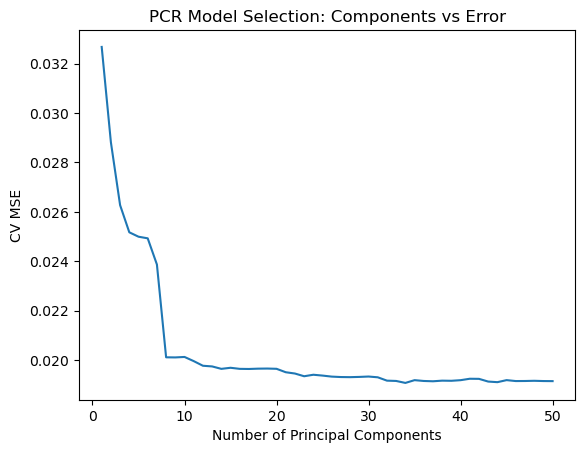

In [17]:
results = pd.DataFrame(pcr_cv.cv_results_)

plt.figure()
plt.plot(results['param_pca__n_components'], -results['mean_test_score'])
plt.xlabel("Number of Principal Components")
plt.ylabel("CV MSE")
plt.title("PCR Model Selection: Components vs Error")
plt.show()

### Best Model Performance Graph


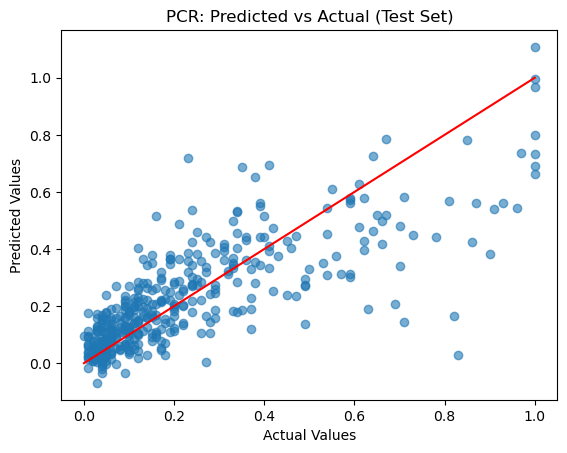

In [18]:
plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("PCR: Predicted vs Actual (Test Set)")
plt.show()

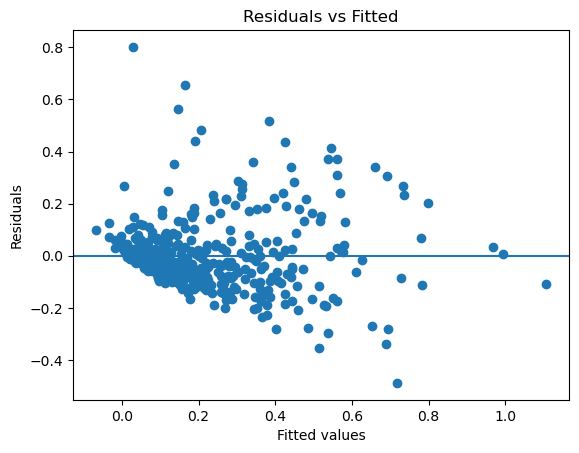

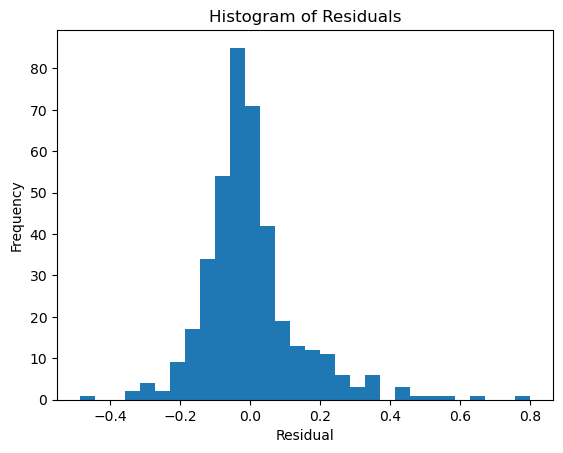

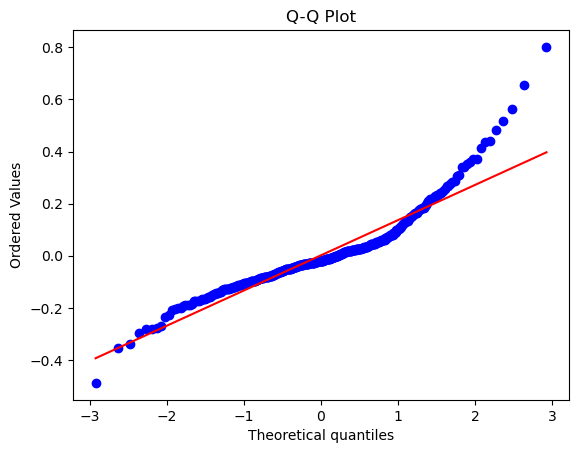

In [ ]:


# Residuals
residuals = y_test - y_pred

# 1. Residuals vs Fitted (check linearity & homoscedasticity)
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# 2. Histogram of residuals (check distribution & skewness)
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# 3. Q-Q Plot (check normality)
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()





### Report

Principal Component Regression (PCR) was applied to the Communities and Crime dataset to predict violent crime rates by transforming high-dimensional socio-economic variables into orthogonal components. The model selection process, illustrated by the CV MSE plot, showed a sharp decrease in error within the first 10 components before reaching a plateau. While 34 components were ultimately selected to minimize error, the model performance—characterized by a Training $R^2$ of 0.67 and a Test $R^2$ of 0.62—suggests a stable fit with minimal overfitting. However, the Predicted vs. Actual plot indicates that the model is more accurate at lower crime rates and tends to underpredict extreme cases, particularly those at the upper bound of the dataset.


Diagnostic analysis of the residuals reveals several violations of standard linear assumptions that limit the model's predictive power. The Residuals vs. Fitted plot displays a clear funnel shape, indicating heteroscedasticity where the variance of error increases alongside the fitted values. Furthermore, the Histogram of Residuals and the Q-Q Plot highlight a significant right-skew and heavy upper tail, confirming that the residuals are not normally distributed. These patterns suggest that the model struggle to capture the non-linear dynamics inherent in high-crime communities. While PCR successfully addresses multicollinearity and provides a solid baseline, future iterations would likely benefit from response transformations or non-linear modeling techniques to better account for the skewed distribution and changing variance identified in these diagnostics.